# Choosing a forecast horizon and a training window with Optuna

Two questions come up in every forecasting project: **how far ahead** should the model predict
(the *horizon*), and **how much history** should it be trained on (the *window*)?

Both are model selection problems, just like a learning rate or a number of layers. So we treat
them as such: we score each candidate with a proper time series cross-validation, and we let
[Optuna](https://optuna.org/) search the space and keep track of the results.

**What you will do here**

1. Score a configuration with `ontime`'s cross-validation helpers.
2. Sweep a list of candidate horizons and read the results table.
3. Sweep the horizon and the training window together.
4. Look at the horizon / accuracy trade-off as a Pareto front.

**Requirements:** `optuna`, which ships with the `dev` dependency group of onTime
(`pip install optuna` otherwise).

In [1]:
# Import to be able to import python package from src
import sys
sys.path.insert(0, '../../src')

In [2]:
import warnings

import numpy as np
import pandas as pd
import optuna

import ontime as on
from ontime.module.processing.cross_validation import evaluate_cross_validation
from ontime.module.benchmarking import BenchmarkMetric

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Setup

### The data

A synthetic hourly series with a daily seasonality, a weekly seasonality and a mild trend, so
the notebook runs fast and offline. Replace it with your own `on.TimeSeries` to reuse the code
as is.

In [3]:
index = pd.date_range(start="2023-01-01", periods=24 * 60, freq="h")
t = np.arange(len(index))

daily = 10 * np.sin(2 * np.pi * t / 24)
weekly = 4 * np.sin(2 * np.pi * t / (24 * 7))
trend = 0.002 * t
noise = np.random.normal(scale=1.5, size=len(t))

df = pd.DataFrame({"consumption": 50 + daily + weekly + trend + noise}, index=index)
ts = on.TimeSeries.from_dataframe(df)

print(f"{len(ts)} points, from {index[0]} to {index[-1]}")
ts[: 24 * 7].plot()

1440 points, from 2023-01-01 00:00:00 to 2023-03-01 23:00:00


alt.LayerChart(...)

### The scoring function

Everything below relies on one function: given a horizon and a training window, return the
cross-validated error of a model.

`evaluate_cross_validation` does the work. It builds the folds, refits the model on the train
set of each fold, predicts `horizon` steps ahead and aggregates the metric across folds. We use
the **sliding** strategy so the training window stays a real degree of freedom (with
`expanding`, the train set grows from fold to fold).

The metric is the **MASE**, which divides the error by that of a naive forecast. Being
scale-free, it is easier to compare from one configuration to the next than a raw error.

In [4]:
from darts.metrics import mase

MASE = BenchmarkMetric(name="mase", metric_function=mase)
N_SPLITS = 5


def evaluate(model, horizon, window):
    """Mean and std of the cross-validated MASE for a horizon and a training window."""
    results = evaluate_cross_validation(
        model,
        ts,
        metrics=MASE,
        n_splits=N_SPLITS,
        strategy="sliding",
        initial_train_size=window,
        horizon=horizon,
    )
    return results["mean"]["mase"], results["std"]["mase"]

A quick check with a seasonal naive model, before letting Optuna drive:

In [5]:
from darts.models import NaiveSeasonal

mean, std = evaluate(on.Model(NaiveSeasonal(K=24)), horizon=24, window=24 * 14)
print(f"MASE = {mean:.3f} (+/- {std:.3f})")

MASE = 1.307 (+/- 0.267)


## 2. Sweeping a list of horizons

The simplest sweep: a fixed list of candidate horizons, one cross-validation each, one table of
results.

In Optuna terms this is a study with a **`GridSampler`**: the search space is enumerated and the
study stops once every combination has been tried. Compared to a hand-written loop we get the
results bookkeeping, the best trial, and later on the pruning and the dashboard for free.

In [6]:
from darts.models import LinearRegressionModel

HORIZONS = [1, 3, 6, 12, 24, 48]
WINDOW = 24 * 21


def horizon_objective(trial):
    horizon = trial.suggest_categorical("horizon", HORIZONS)
    model = on.Model(LinearRegressionModel(lags=48, random_state=RANDOM_STATE))
    mean, std = evaluate(model, horizon=horizon, window=WINDOW)
    trial.set_user_attr("mase_std", float(std))
    return mean


horizon_study = optuna.create_study(
    study_name="horizon_sweep",
    direction="minimize",
    sampler=optuna.samplers.GridSampler({"horizon": HORIZONS}, seed=RANDOM_STATE),
)
horizon_study.optimize(horizon_objective)

In [7]:
results = (
    horizon_study.trials_dataframe(attrs=("params", "value", "user_attrs"))
    .rename(
        columns={
            "params_horizon": "horizon",
            "value": "mase",
            "user_attrs_mase_std": "mase_std",
        }
    )
    .sort_values("horizon")
    .set_index("horizon")
)
results

,mase,mase_std
horizon,,
1,0.492685,0.251522
3,0.431817,0.045623
6,0.523251,0.068379
12,0.508320,0.102901
24,0.550760,0.083044
48,0.670632,0.230549


In [8]:
print(f"Best horizon: {horizon_study.best_params['horizon']}")
print(f"Best MASE:    {horizon_study.best_value:.3f}")

Best horizon: 3
Best MASE:    0.432


### Careful: the shortest horizon almost always wins

This is the trap of any horizon sweep. Predicting one step ahead is easier than predicting
forty-eight, so minimizing an error over a list of horizons tends to return the shortest one.
That is a true, but useless, answer.

The table above is the interesting artifact: it shows *how fast* the error grows with the
horizon. Three ways to turn it into a decision:

| The question you are really asking | How to set up the search |
| --- | --- |
| Which window and model are best **for the horizon my use case imposes**? | Fix the horizon, sweep the rest. |
| How far ahead can I forecast **before the error crosses my budget**? | Sweep horizons, compare to a threshold. |
| What is the best **trade-off** between horizon and accuracy? | Multi-objective, look at the Pareto front. |

The next cells illustrate the error budget, then section 4 covers the trade-off.

In [9]:
MASE_BUDGET = 0.6

within_budget = results[results["mase"] <= MASE_BUDGET]
if len(within_budget):
    print(f"Longest horizon with MASE <= {MASE_BUDGET}: {within_budget.index.max()}")
else:
    print(f"No horizon reaches a MASE <= {MASE_BUDGET}")

Longest horizon with MASE <= 0.6: 24


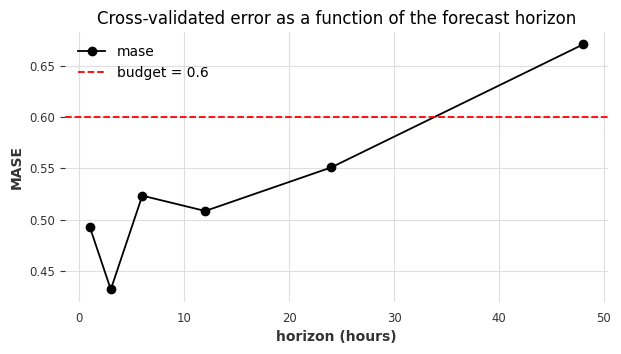

In [10]:
ax = results["mase"].plot(marker="o", figsize=(7, 3.5))
ax.axhline(MASE_BUDGET, color="red", linestyle="--", label=f"budget = {MASE_BUDGET}")
ax.set_xlabel("horizon (hours)")
ax.set_ylabel("MASE")
ax.set_title("Cross-validated error as a function of the forecast horizon")
ax.legend()

## 3. Sweeping the horizon and the window together

The training window is the other half of the question, and the two interact: a longer horizon
often needs more history to stay predictable. A nested loop would work, but the space grows
quickly, so we switch to the default **TPE sampler**, which samples promising regions instead of
enumerating everything.

Two details worth noting:

- `optuna.TrialPruned` discards configurations that make no sense or do not fit in the series,
  which keeps the study clean without aborting the sweep;
- the number of lags of the model is thrown into the same search, since it is tied to the window.

In [11]:
def horizon_window_objective(trial):
    horizon = trial.suggest_categorical("horizon", HORIZONS)
    window = trial.suggest_int("window", 24 * 3, 24 * 30, step=24)
    lags = trial.suggest_int("lags", 24, 96, step=24)

    if lags >= window:
        raise optuna.TrialPruned("lags must be shorter than the training window")

    model = on.Model(LinearRegressionModel(lags=lags, random_state=RANDOM_STATE))
    try:
        mean, _ = evaluate(model, horizon=horizon, window=window)
    except ValueError as e:
        raise optuna.TrialPruned(str(e))
    return mean


joint_study = optuna.create_study(
    study_name="horizon_window_sweep",
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
joint_study.optimize(horizon_window_objective, n_trials=30)

print(f"Best params: {joint_study.best_params}")
print(f"Best MASE:   {joint_study.best_value:.3f}")

Best params: {'horizon': 1, 'window': 552, 'lags': 24}
Best MASE:   0.397


Since the horizon dominates the error, the global best is once again the shortest horizon. Group
the trials by horizon instead: each row is then the best window and lags **for that horizon**,
which is what you actually deploy.

In [12]:
trials = joint_study.trials_dataframe(attrs=("params", "value", "state"))
trials = trials[trials["state"] == "COMPLETE"]

best_per_horizon = (
    trials.sort_values("value")
    .groupby("params_horizon")
    .first()[["params_window", "params_lags", "value"]]
    .rename(columns={"params_window": "window", "params_lags": "lags", "value": "mase"})
    .round(3)
)
best_per_horizon.index.name = "horizon"
best_per_horizon

,window,lags,mase
horizon,,,
1,552,24,0.397
3,288,24,0.436
6,528,48,0.552
12,264,72,0.644
24,264,48,0.546
48,720,48,0.599


## 4. The horizon / accuracy trade-off

The most honest phrasing of the problem: *forecast as far as possible, as accurately as
possible*. These two goals conflict, so there is no single best horizon, there is a **Pareto
front**. Optuna handles multi-objective studies natively, just return a tuple and give one
direction per objective.

In [13]:
def pareto_objective(trial):
    horizon = trial.suggest_categorical("horizon", HORIZONS)
    window = trial.suggest_int("window", 24 * 7, 24 * 30, step=24 * 7)
    lags = trial.suggest_int("lags", 24, 96, step=24)
    if lags >= window:
        raise optuna.TrialPruned("lags must be shorter than the training window")

    model = on.Model(LinearRegressionModel(lags=lags, random_state=RANDOM_STATE))
    try:
        mean, _ = evaluate(model, horizon=horizon, window=window)
    except ValueError as e:
        raise optuna.TrialPruned(str(e))
    return mean, float(horizon)  # minimize the error, maximize the horizon


pareto_study = optuna.create_study(
    study_name="horizon_pareto",
    directions=["minimize", "maximize"],
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
pareto_study.optimize(pareto_objective, n_trials=40)

In [14]:
front = (
    pd.DataFrame(
        [
            {
                "horizon": int(t.values[1]),
                "mase": round(t.values[0], 3),
                "window": t.params["window"],
                "lags": t.params["lags"],
            }
            for t in pareto_study.best_trials
        ]
    )
    .drop_duplicates()
    .sort_values("horizon")
    .reset_index(drop=True)
)
front

,horizon,mase,window,lags
0,1,0.247,672,24
1,3,0.381,336,48
2,12,0.508,504,48
3,24,0.551,504,48
4,48,0.599,672,48


Each row is a non-dominated configuration: nothing tested forecasts further *and* more
accurately. Choosing one is now a business decision rather than a statistical one.

## What to remember

- Score a configuration with `evaluate_cross_validation`, let Optuna choose which ones to try.
- Use `GridSampler` for an exhaustive sweep, the default TPE sampler for larger spaces.
- Never pick a horizon by minimizing an error alone: use a budget, a fixed horizon, or a
  Pareto front.

## Going further

- **Several models at once.** Suggest the model as a categorical parameter and build it inside
  the objective. Optuna supports conditional spaces, so each model can have its own
  hyperparameters, and you get a model x horizon comparison in a single study.
- **Persistence and dashboard.** Pass `storage="sqlite:///horizon_sweep.db"` and
  `load_if_exists=True` to `optuna.create_study` to resume a sweep, then inspect it with
  `optuna-dashboard sqlite:///horizon_sweep.db`.
- **Parallelism.** `study.optimize(..., n_jobs=-1)` runs trials in parallel, and with a shared
  storage several processes can feed the same study.
- **Pruning.** For deep models, stop hopeless trials early with a pruner, as shown in
  [Optimize model hyperparameters using Optuna](1_optimize-model-hyperparameters-optuna.ipynb).
- **Other validation schemes.** `evaluate_cross_validation` also accepts
  `strategy="expanding"` or `"blocked"`, and a `gap` for purged validation. See the
  [cross-validation guide](../user_guide/1_module/1-processing/1.1-cross-validation.ipynb).
- **Parameter importance.** How much does the horizon really matter compared to the rest?

In [15]:
optuna.importance.get_param_importances(joint_study)

{'window': 0.7039159264526447,
 'horizon': 0.20179455288155612,
 'lags': 0.09428952066579922}